# Python Implementation of Multiple Linear Regression
Multiple Linear Regression is a extended version of it only. It attempts to model relationship between two or more features to fit a linear equation to predict one dependent variable.

## Steps for Multiple Linear Regression
Steps to perform multiple linear Regression are almost similar to that of simple linear Regression difference Lies in the evaluation. We can use it to find out which factor has the highest impact on the predicted output and how different variables relate to each other.

The goal of the algorithm is to find the best fit line equation that can predict the values based on the independent variables. 

### Handling Categorical Data with Dummy Variables
In multiple regression model, we often encounter categorical data, such as gender (male/female), location (urban/rural), etc. Since regression models typically expect numerical inputs, categorical data must be transformed into a usable form.

This is where Dummy Variables come into play. Dummy variables are binary variables (0 or 1) that represent the presence or absence of each category. For example:

Male: 1 if male, 0 otherwise
Female: 1 if female, 0 otherwise

In the case of multiple categories (e.g., color: “Red”, “Blue”, “Green”), we create a dummy variable for each category, excluding one to avoid multicollinearity. This process is called one-hot encoding, which converts categorical variables into a format suitable for regression models.

### Multicollinearity in Multiple Linear Regression
When building a multiple linear regression model, multicollinearity can arise. It occurs when two or more independent variables are highly correlated with each other. 

This can make it difficult to evaluate the individual contribution of each variable to the dependent variable.

#### Detecting Multicollinearity includes two techniques:

Correlation Matrix: Examining the correlation matrix among the independent variables is a common way to detect multicollinearity. High correlations (close to 1 or -1) indicate potential multicollinearity.

VIF (Variance Inflation Factor): VIF is a measure that quantifies how much the variance of an estimated regression coefficient increases if your predictors are correlated. A high VIF (typically above 10) suggests multicollinearity.


## For multiple linear regression using Python, we will use the California house pricing dataset. 



In [2]:
# necesary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle
from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE, mutual_info_regression

Matplotlib is building the font cache; this may take a moment.


# load data

In [5]:
def wrangle(filepath):
    # Determine file type and read data
    if filepath.endswith('.csv'):
        df = pd.read_csv(filepath)
    else:
        df = pd.read_excel(filepath)

    # Filter medianHouseValue between 75000 and 350000
    df = df[(df["medianHouseValue"] >= 75000) & (df["medianHouseValue"] <= 350000)]

    # Compute quantiles for filtering
    quantiles = df[['totalBedrooms', 'totalRooms']].quantile([0.1, 0.9])
    low, high = quantiles.loc[0.1], quantiles.loc[0.9]

    # Apply range filtering
    mask_bedrooms = df['totalBedrooms'].between(low['totalBedrooms'], high['totalBedrooms'])
    mask_rooms = df['totalRooms'].between(low['totalRooms'], high['totalRooms'])
    df = df[mask_bedrooms & mask_rooms]

    # Drop unwanted columns
    columns_to_drop = ['averageOccupantsPerHousehold', 'population']
    df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

    return df

In [9]:
df = wrangle("C:\\Users\\franc\\Datascience_python\\dataset\\cal_housing.xlsx")
print(df.head())

   longitude  latitude  housingMedianAge  totalRooms  totalBedrooms  \
3    -122.25     37.85              52.0      1274.0          235.0   
4    -122.25     37.85              52.0      1627.0          280.0   
6    -122.25     37.84              52.0      2535.0          489.0   
7    -122.25     37.84              52.0      3104.0          687.0   
8    -122.26     37.84              42.0      2555.0          665.0   

   households  medianIncome  medianHouseValue  
3       219.0        5.6431          341300.0  
4       259.0        3.8462          342200.0  
6       514.0        3.6591          299200.0  
7       647.0        3.1200          241400.0  
8       595.0        2.0804          226700.0  


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12460 entries, 3 to 20639
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   longitude         12460 non-null  float64
 1   latitude          12460 non-null  float64
 2   housingMedianAge  12460 non-null  float64
 3   totalRooms        12460 non-null  float64
 4   totalBedrooms     12460 non-null  float64
 5   households        12460 non-null  float64
 6   medianIncome      12460 non-null  float64
 7   medianHouseValue  12460 non-null  float64
dtypes: float64(8)
memory usage: 876.1 KB
None


# explore

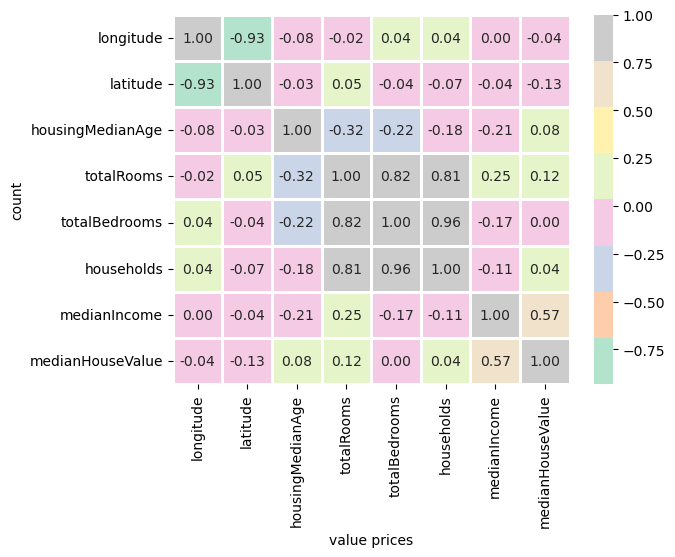

In [14]:
# heatmap seaborn

sns.heatmap(df.corr(), annot=True, fmt = '.2f',cmap="Pastel2", linewidths=1)

plt.hist(df['medianHouseValue'])
plt.xlabel("value prices")
plt.ylabel("count")
plt.show();

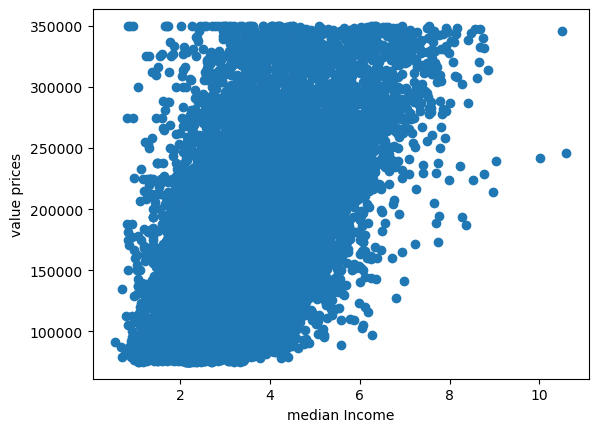

In [15]:
# scatter plot  matplotlib
plt.scatter(df["medianIncome"],df['medianHouseValue'])
plt.xlabel("median Income")
plt.ylabel("value prices")
plt.show();

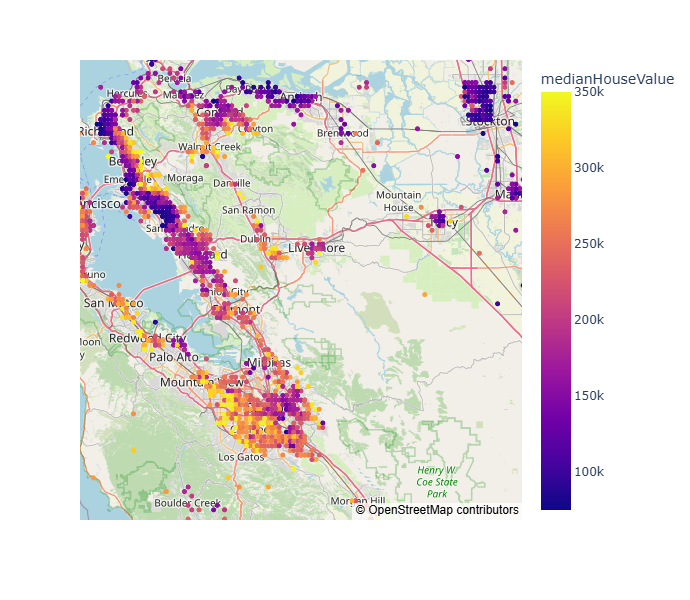

In [19]:
# mapbox scatter plot
fig = px.scatter_mapbox(
    df,
    lat= 'latitude',
    lon= 'longitude',
    center= {'lat':37.59,"lon":-121.81},
    width = 1000,
    height= 600,
    color = 'medianHouseValue'
)
fig.update_layout(mapbox_style = "open-street-map")
fig.show()


# split

In [833]:
# define feature & target
target = df["medianHouseValue"]
y = pd.Series(target)
print(y.shape)
feature = ["medianIncome",'longitude', 'latitude', 'housingMedianAge', 'totalRooms','totalBedrooms', 'households']
X = df[feature]
print(X.shape)

(12460,)
(12460, 7)


In [834]:
# train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f"XtrainShape:{X_train.shape},")
print(f"XtestShape:{X_test.shape},")
print(f"ytrainShape:{y_train.shape},")
print(f"ytestShape:{y_test.shape},")

XtrainShape:(9968, 7),
XtestShape:(2492, 7),
ytrainShape:(9968,),
ytestShape:(2492,),


In [835]:
# Recursive Feature Elimination (RFE)
# create linear regression model
model = linear_model.LinearRegression()
model_selector = RFE(model, n_features_to_select=3)

# train the model on training data
model_selector.fit(X_train,y_train)
selected_feats = X.columns[model_selector.support_]
print("selected feats using RFE:", selected_feats.tolist())

# re split using the selected feats
X = df[selected_feats]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


selected feats using RFE: ['medianIncome', 'longitude', 'latitude']


# Build model 

In [837]:
# baseline
y_mean = y_train.mean()
print("y_mean:",y_mean)
y_pred_baseline = [y_mean] * len(y_train)

mae = metrics.mean_absolute_error(y_train,y_pred_baseline)
print("mae:",mae)

y_mean: 184334.911717496
mae: 57987.754828291625


In [838]:
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

# Predict house prices for the test set
y_pred = model.predict(X_test) 

# mean absolute error
mae = metrics.mean_absolute_error(y_test,y_pred)
print("mae:",mae);

mae: 39852.79069631045


In [839]:
# Display the first few predictions alongside the actual values
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions.head(5))

         Actual      Predicted
17395  104200.0  220335.101392
14990  126900.0  195371.791278
9220    81500.0  137722.496520
4180   165000.0  164610.437149
4403   156300.0  141919.254848


In [840]:
# Save the trained model to a file
with open("house_price_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


# communicate

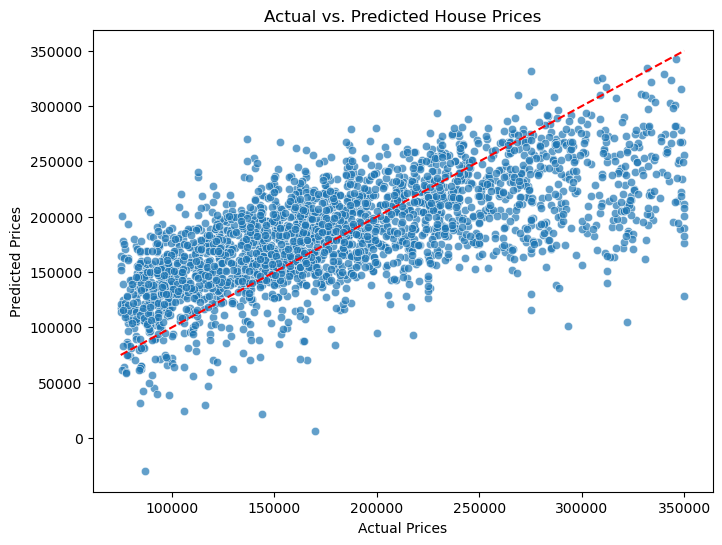

In [842]:
# communicate
# Scatter plot for actual vs. predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')  # 45-degree line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.show();

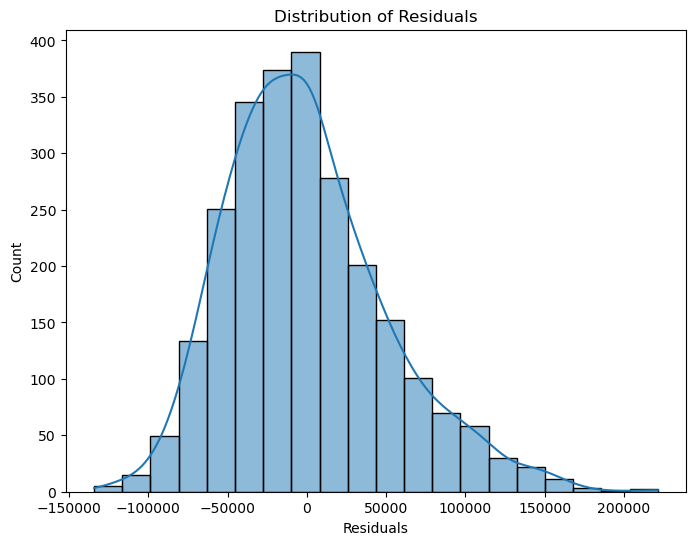

In [843]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=20, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show;

# predictin function

In [867]:
# Function to load the model and make predictions
def make_prediction(medianIncome, longitude, latitude,model_path="house_price_model.pkl"):
    # Load the trained model
    with open(model_path, "rb") as f:
        loaded_model = pickle.load(f)

    # Create input DataFrame
    features = pd.DataFrame([[medianIncome, longitude, latitude]], columns=['medianIncome', 'longitude', 'latitude'])

    # Predict price
    predicted_price = loaded_model.predict(features)[0]

    return predicted_price

#  usage
predicted_price = make_prediction(2,-122.42,27.77)
print(f"Predicted House Price: ${predicted_price:,.2f}")

Predicted House Price: $529,861.48


# method 2

In [722]:
# Loading the Califonia Housing Dataset
cali = datasets.fetch_california_housing()

print(cali.keys())

# print(df.describe())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [726]:
# Loading the Califonia Housing Dataset
cali = datasets.fetch_california_housing()

df = pd.DataFrame(cali.data, columns=cali.feature_names)

Training set size: (16512, 8)
Testing set size: (4128, 8)
selected feats using RFE: ['MedInc', 'AveBedrms', 'Latitude', 'Longitude']


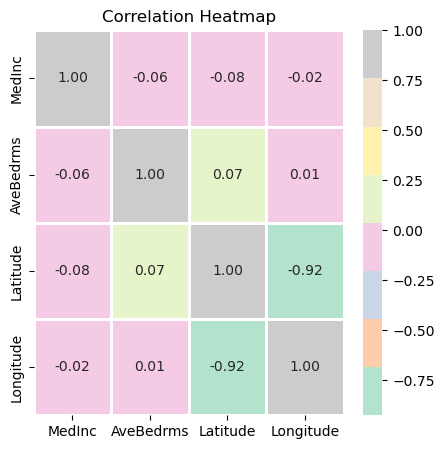

Training set size: (16512, 4)
Testing set size: (4128, 4)
        Actual  Predicted
20046  0.47700   0.733290
3024   0.45800   1.784553
15663  5.00001   2.337396
20484  2.18600   2.985304
9814   2.78000   2.728930
13311  1.58700   2.120436
7113   1.98200   2.591815
7668   1.57500   2.083288
18246  3.40000   2.816513
5723   4.46600   3.657056


In [734]:
X = df
y = pd.Series(cali.target)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Method 1: Recursive Feature Elimination (RFE)
# create linear regression model
model = linear_model.LinearRegression()
model_selector = RFE(model, n_features_to_select=4)
# train the model on training data
model_selector.fit(X_train,y_train)
selected_feats = X.columns[model_selector.support_]
print("selected feats using RFE:", selected_feats.tolist())

X = df[['MedInc', 'AveBedrms', 'Latitude', 'Longitude']] 
y = pd.Series(cali.target)


# correlation of selected feats
plt.figure(figsize=(5,5))
# plotting the heatmap for correlation
sns.heatmap(df[selected_feats].corr(), annot=True, fmt = '.2f',cmap="Pastel2", linewidths=1)

plt.title('Correlation Heatmap')
plt.show();

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

model = linear_model.LinearRegression()
model.fit(X_train, y_train)

# Predict house prices for the test set
y_pred = model.predict(X_test)

# Display the first few predictions alongside the actual values
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions.head(10))




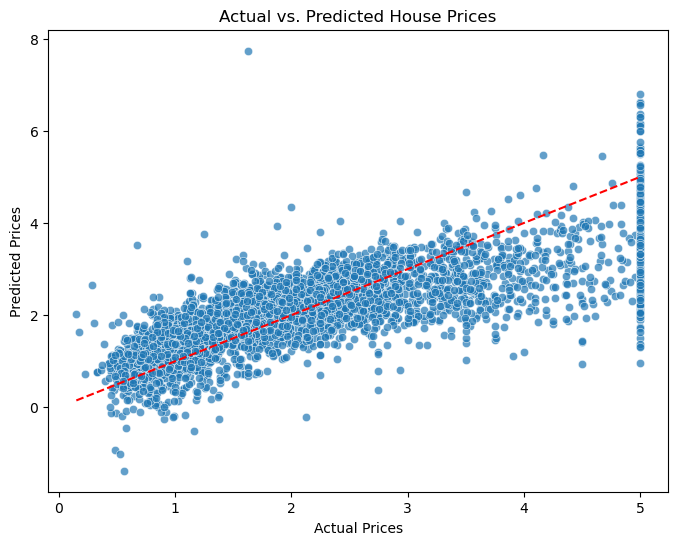

In [730]:
# Scatter plot for actual vs. predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')  # 45-degree line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.show();


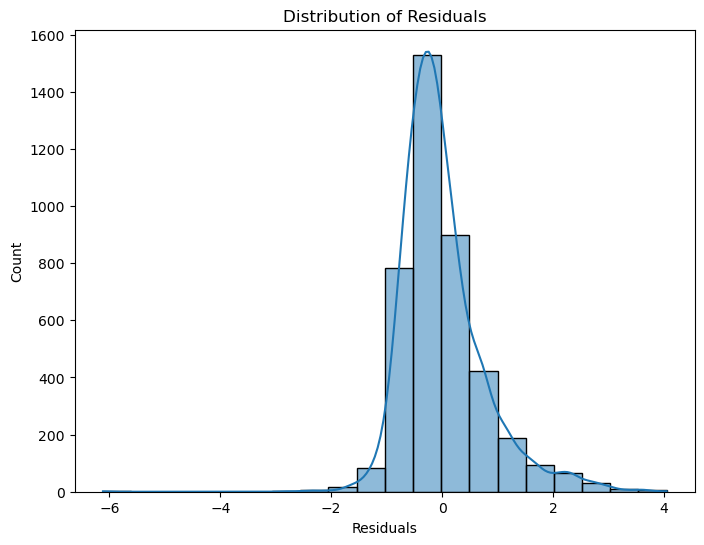

In [732]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=20, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show;